# Analyse de données de simulation CFD — Propulsion cryogénique

**Techniques** : Clustering (K-Means, DBSCAN), Réduction de dimensions (PCA, t-SNE), Régression (Gradient Boosting, MLP)

## Contexte

On génère un dataset synthétique représentant des mesures capteurs sur une chambre de combustion
cryogénique : température de paroi, pression chambre, débit injecteurs, vibrations.
L'objectif est d'appliquer les techniques classiques d'analyse de données de simulation :

1. **Clustering** pour identifier les régimes de fonctionnement
2. **Réduction de dimensions** pour visualiser l'espace des paramètres
3. **Régression** pour prédire la température de paroi à partir des paramètres opératoires


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score

np.random.seed(42)


## Génération du dataset synthétique

Le dataset simule 3 régimes de fonctionnement d'un moteur cryogénique :
- **Nominal** : fonctionnement stable, rapport de mélange optimal
- **Transitoire allumage** : montée en pression, températures basses
- **Off-design** : rapport de mélange décalé, températures élevées


In [2]:
def generate_engine_data(n_samples=3000):
    data = []
    labels = []

    # Régime 1: Nominal (stable)
    n1 = n_samples // 3
    P_chamber = np.random.normal(100, 3, n1)       # bar
    OF_ratio = np.random.normal(6.0, 0.2, n1)      # O/F ratio
    mdot_ox = np.random.normal(250, 8, n1)          # kg/s
    mdot_fuel = mdot_ox / OF_ratio
    T_wall = 800 + 20 * (P_chamber - 100) + 50 * (OF_ratio - 6) + np.random.normal(0, 15, n1)
    vibration = np.random.normal(2.0, 0.5, n1)      # g RMS
    T_injector = np.random.normal(95, 5, n1)         # K (LOx)
    eta_c = 0.97 + 0.005 * np.random.randn(n1)      # combustion efficiency

    for i in range(n1):
        data.append([P_chamber[i], OF_ratio[i], mdot_ox[i], mdot_fuel[i],
                     T_wall[i], vibration[i], T_injector[i], eta_c[i]])
        labels.append("nominal")

    # Régime 2: Transitoire allumage
    n2 = n_samples // 3
    t_phase = np.linspace(0, 1, n2)
    P_chamber = 10 + 90 * t_phase + np.random.normal(0, 5, n2)
    OF_ratio = 4.0 + 2.0 * t_phase + np.random.normal(0, 0.5, n2)
    mdot_ox = 30 + 220 * t_phase + np.random.normal(0, 10, n2)
    mdot_fuel = mdot_ox / np.clip(OF_ratio, 2, 10)
    T_wall = 300 + 500 * t_phase + np.random.normal(0, 30, n2)
    vibration = 8.0 - 6.0 * t_phase + np.random.normal(0, 1.0, n2)
    T_injector = 90 + np.random.normal(0, 8, n2)
    eta_c = 0.85 + 0.12 * t_phase + 0.01 * np.random.randn(n2)

    for i in range(n2):
        data.append([P_chamber[i], OF_ratio[i], mdot_ox[i], mdot_fuel[i],
                     T_wall[i], vibration[i], T_injector[i], eta_c[i]])
        labels.append("transient")

    # Régime 3: Off-design (OF élevé)
    n3 = n_samples - n1 - n2
    P_chamber = np.random.normal(95, 5, n3)
    OF_ratio = np.random.normal(7.5, 0.3, n3)
    mdot_ox = np.random.normal(260, 10, n3)
    mdot_fuel = mdot_ox / OF_ratio
    T_wall = 1000 + 30 * (OF_ratio - 7.5) + 15 * (P_chamber - 95) + np.random.normal(0, 20, n3)
    vibration = np.random.normal(4.0, 1.0, n3)
    T_injector = np.random.normal(92, 6, n3)
    eta_c = 0.93 + 0.01 * np.random.randn(n3)

    for i in range(n3):
        data.append([P_chamber[i], OF_ratio[i], mdot_ox[i], mdot_fuel[i],
                     T_wall[i], vibration[i], T_injector[i], eta_c[i]])
        labels.append("off_design")

    columns = ["P_chamber_bar", "OF_ratio", "mdot_ox_kgs", "mdot_fuel_kgs",
               "T_wall_K", "vibration_grms", "T_injector_K", "eta_combustion"]
    df = pd.DataFrame(data, columns=columns)
    df["regime"] = labels
    return df

df = generate_engine_data(3000)
print(df.describe().round(2))
print(f"\nRépartition des régimes:\n{df['regime'].value_counts()}")


       P_chamber_bar  OF_ratio  mdot_ox_kgs  mdot_fuel_kgs  T_wall_K  \
count        3000.00   3000.00      3000.00        3000.00   3000.00   
mean           83.44      6.17       216.74          34.49    784.43   
std            25.58      1.14        66.32           8.55    212.16   
min             1.20      2.48         7.43           1.87    257.71   
25%            78.35      5.58       194.35          32.45    671.33   
50%            95.26      6.06       248.14          35.99    801.31   
75%            99.83      7.30       257.96          40.72    951.11   
max           111.56      8.84       289.80          50.12   1222.19   

       vibration_grms  T_injector_K  eta_combustion  
count         3000.00       3000.00         3000.00  
mean             3.65         92.34            0.94  
std              1.83          6.67            0.03  
min             -0.72         67.74            0.83  
25%              2.16         88.19            0.92  
50%              3.37      

## Exploration des données

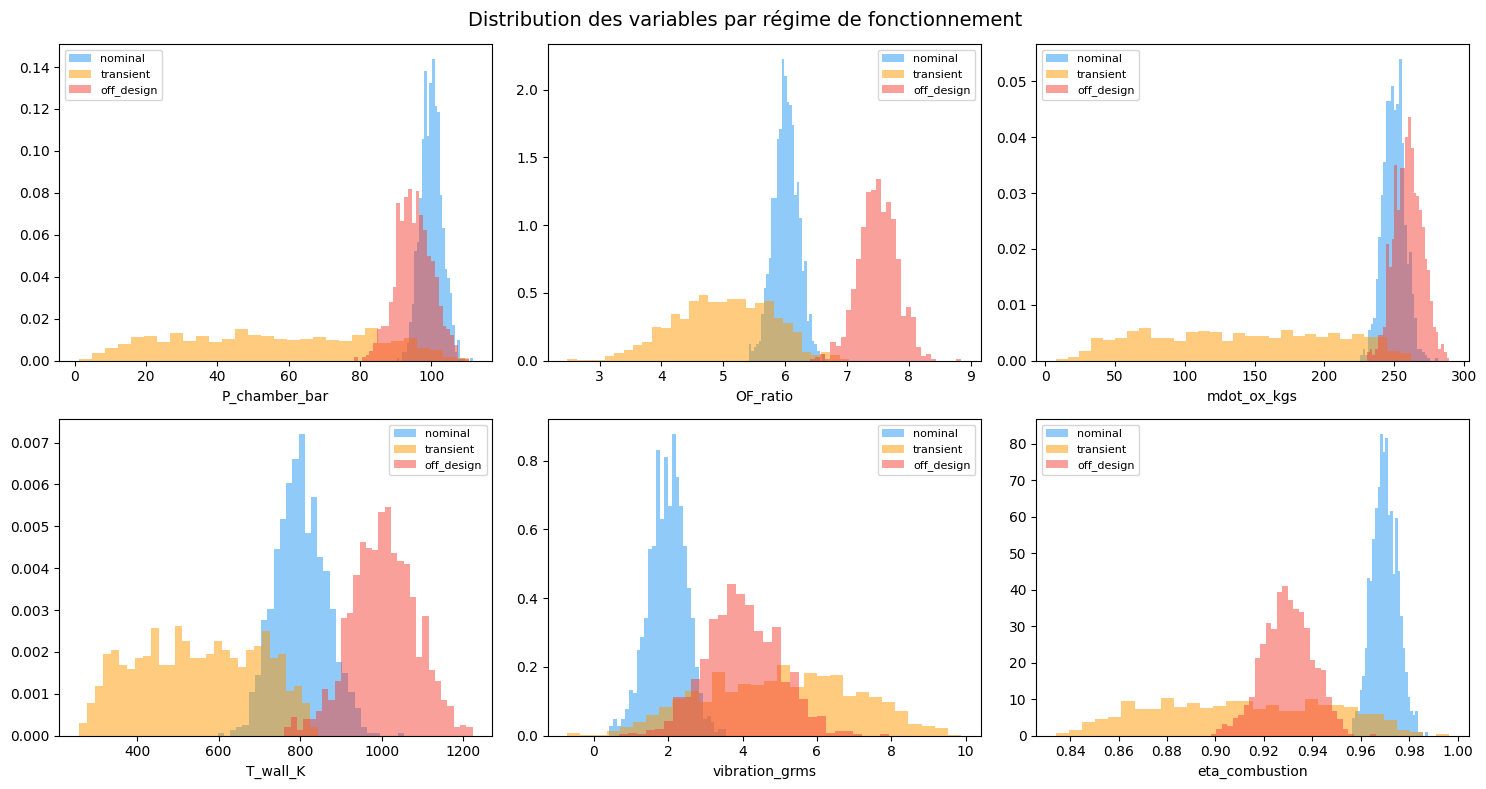

In [3]:
features = ["P_chamber_bar", "OF_ratio", "mdot_ox_kgs", "T_wall_K", "vibration_grms", "eta_combustion"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = {"nominal": "#2196F3", "transient": "#FF9800", "off_design": "#F44336"}

for ax, feat in zip(axes.flatten(), features):
    for regime, color in colors.items():
        subset = df[df["regime"] == regime]
        ax.hist(subset[feat], bins=30, alpha=0.5, label=regime, color=color, density=True)
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)

fig.suptitle("Distribution des variables par régime de fonctionnement", fontsize=14)
plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## Réduction de dimensions

### PCA — Analyse en composantes principales


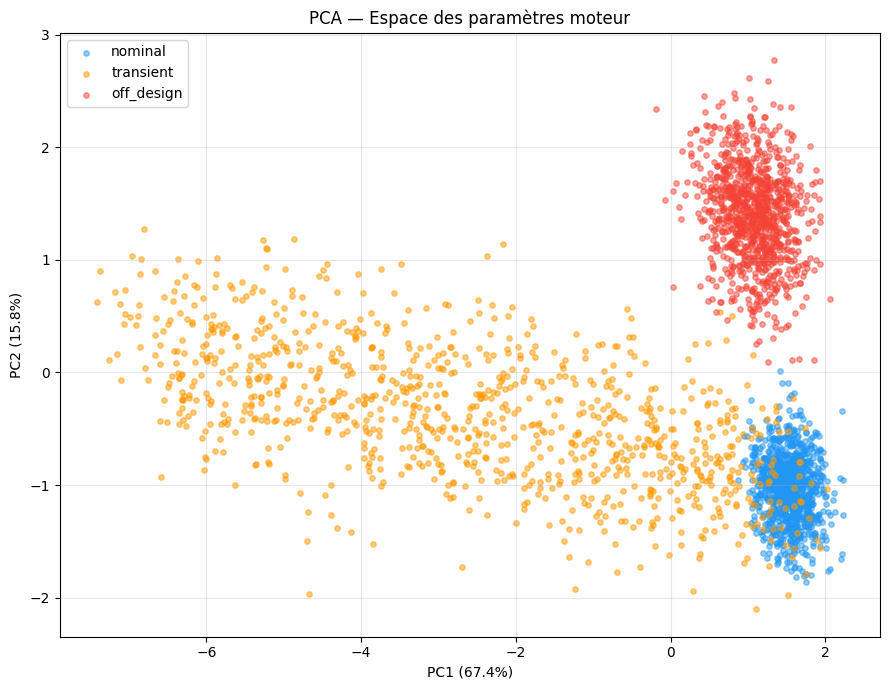

Variance expliquée par composante: [0.674 0.158]
Variance cumulée: [0.674 0.832]


In [4]:
feature_cols = ["P_chamber_bar", "OF_ratio", "mdot_ox_kgs", "mdot_fuel_kgs",
                "T_wall_K", "vibration_grms", "T_injector_K", "eta_combustion"]

X = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for regime, color in colors.items():
    mask = df["regime"] == regime
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=regime, alpha=0.5, s=15)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA — Espace des paramètres moteur")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_projection.png", dpi=150, bbox_inches="tight")
plt.show()

print("Variance expliquée par composante:", pca.explained_variance_ratio_.round(3))
print("Variance cumulée:", pca.explained_variance_ratio_.cumsum().round(3))


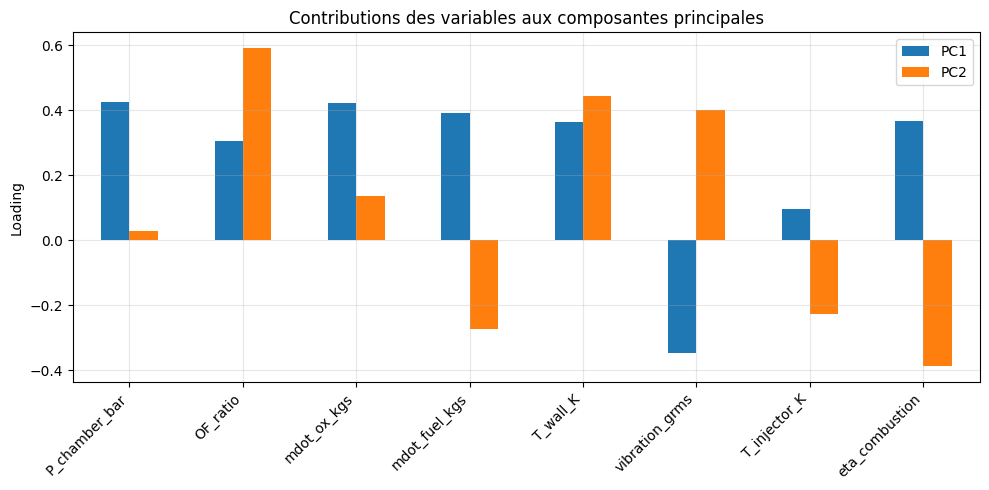

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=["PC1", "PC2"])
loadings.plot(kind="bar", ax=ax)
ax.set_title("Contributions des variables aux composantes principales")
ax.set_ylabel("Loading")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()


### t-SNE

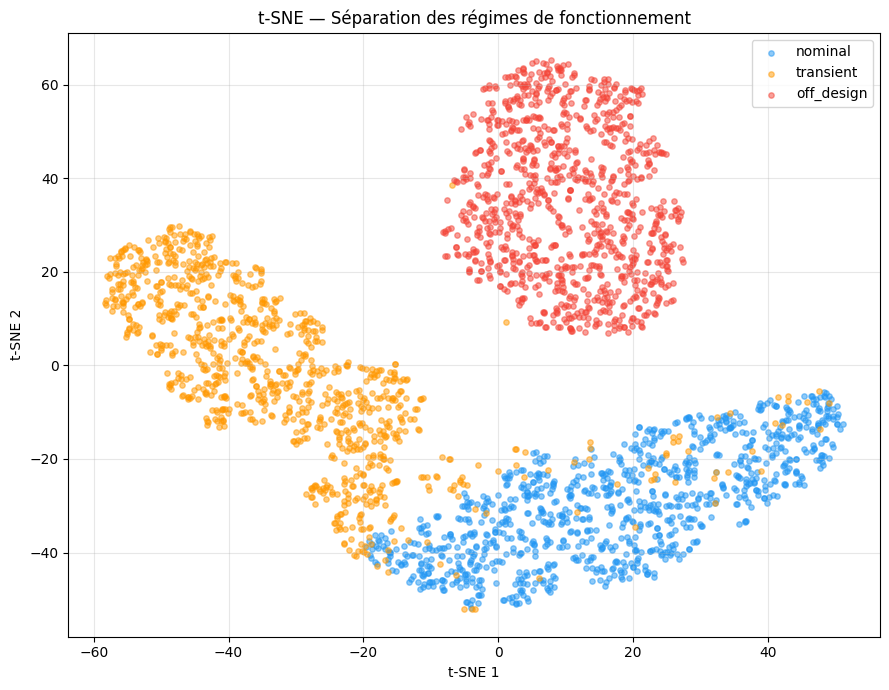

In [6]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for regime, color in colors.items():
    mask = df["regime"] == regime
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=regime, alpha=0.5, s=15)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE — Séparation des régimes de fonctionnement")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tsne_projection.png", dpi=150, bbox_inches="tight")
plt.show()


## Clustering

### K-Means


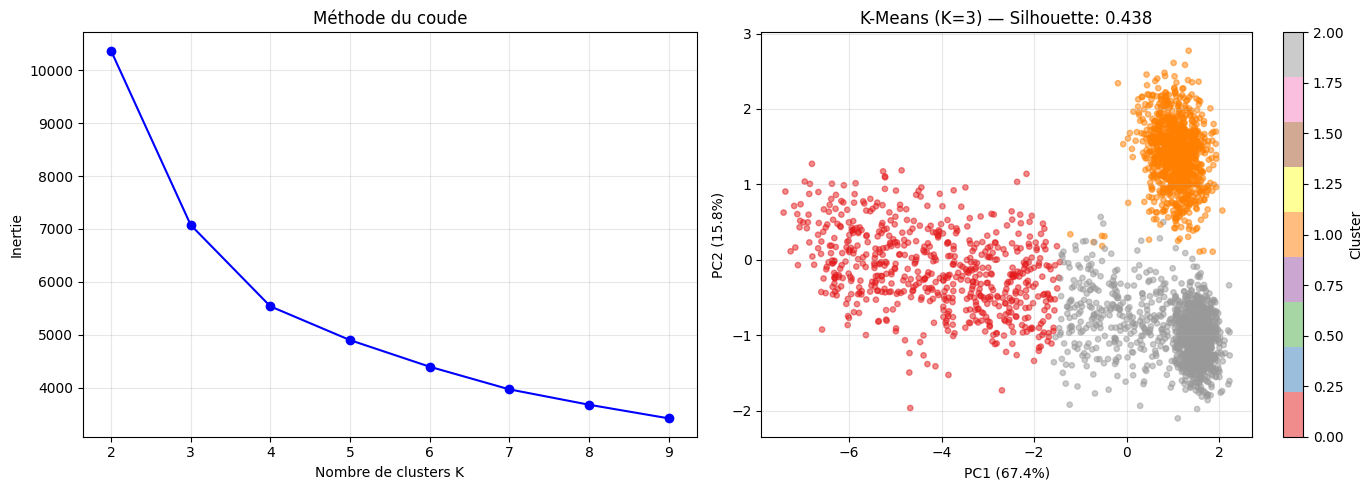

Correspondance clusters / régimes réels:
Cluster       0    1     2
Régime                    
nominal       0    0  1000
off_design    0  999     1
transient   628    7   365


In [7]:
# Elbow method
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, "bo-")
ax1.set_xlabel("Nombre de clusters K")
ax1.set_ylabel("Inertie")
ax1.set_title("Méthode du coude")
ax1.grid(True, alpha=0.3)

# K=3
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km3.fit_predict(X_scaled)
sil_score = silhouette_score(X_scaled, cluster_labels)

scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="Set1", alpha=0.5, s=15)
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_title(f"K-Means (K=3) — Silhouette: {sil_score:.3f}")
plt.colorbar(scatter, ax=ax2, label="Cluster")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_clustering.png", dpi=150, bbox_inches="tight")
plt.show()

# Confusion matrix: clusters vs true regimes
ct = pd.crosstab(df["regime"], cluster_labels, rownames=["Régime"], colnames=["Cluster"])
print("Correspondance clusters / régimes réels:")
print(ct)


### DBSCAN

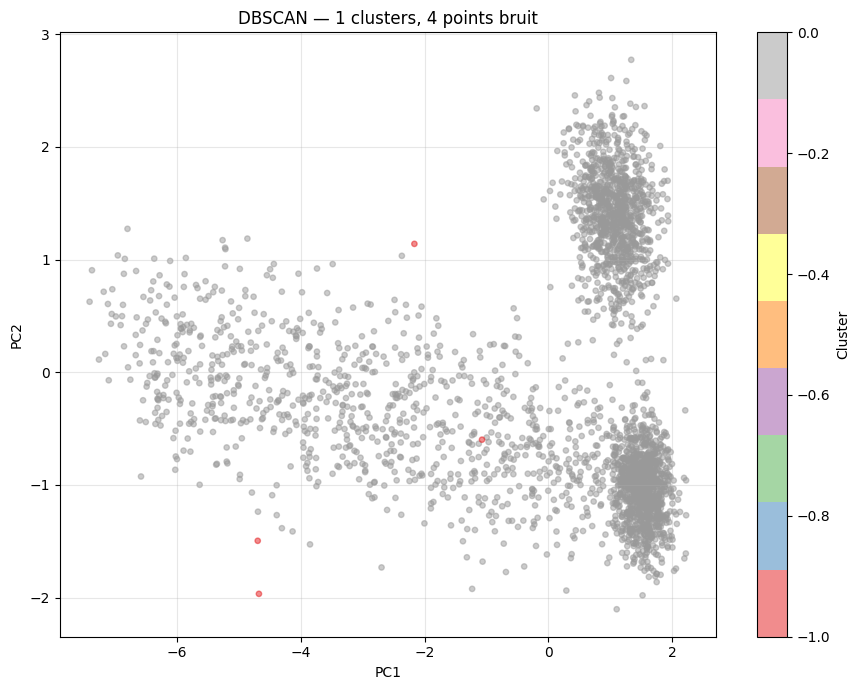

In [8]:
dbscan = DBSCAN(eps=1.5, min_samples=15)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap="Set1", alpha=0.5, s=15)
ax.set_xlabel(f"PC1"); ax.set_ylabel(f"PC2")
ax.set_title(f"DBSCAN — {n_clusters_db} clusters, {n_noise} points bruit")
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_clustering.png", dpi=150, bbox_inches="tight")
plt.show()


## Régression

Prédiction de la température de paroi `T_wall_K` à partir des paramètres opératoires.
On compare Gradient Boosting et un réseau de neurones (MLP).


In [9]:
target = "T_wall_K"
predictors = ["P_chamber_bar", "OF_ratio", "mdot_ox_kgs", "mdot_fuel_kgs",
              "vibration_grms", "T_injector_K", "eta_combustion"]

X_reg = df[predictors].values
y_reg = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_s = scaler_reg.fit_transform(X_train)
X_test_s = scaler_reg.transform(X_test)

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_s, y_train)
y_pred_gb = gb.predict(X_test_s)

# MLP
mlp = MLPRegressor(hidden_layer_sizes=(64, 64, 32), max_iter=1000,
                   random_state=42, early_stopping=True)
mlp.fit(X_train_s, y_train)
y_pred_mlp = mlp.predict(X_test_s)

print("=== Gradient Boosting ===")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.2f} K")
print(f"  R²:   {r2_score(y_test, y_pred_gb):.4f}")
print()
print("=== MLP Regressor ===")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_mlp)):.2f} K")
print(f"  R²:   {r2_score(y_test, y_pred_mlp):.4f}")


=== Gradient Boosting ===
  RMSE: 31.39 K
  R²:   0.9778

=== MLP Regressor ===
  RMSE: 30.83 K
  R²:   0.9785


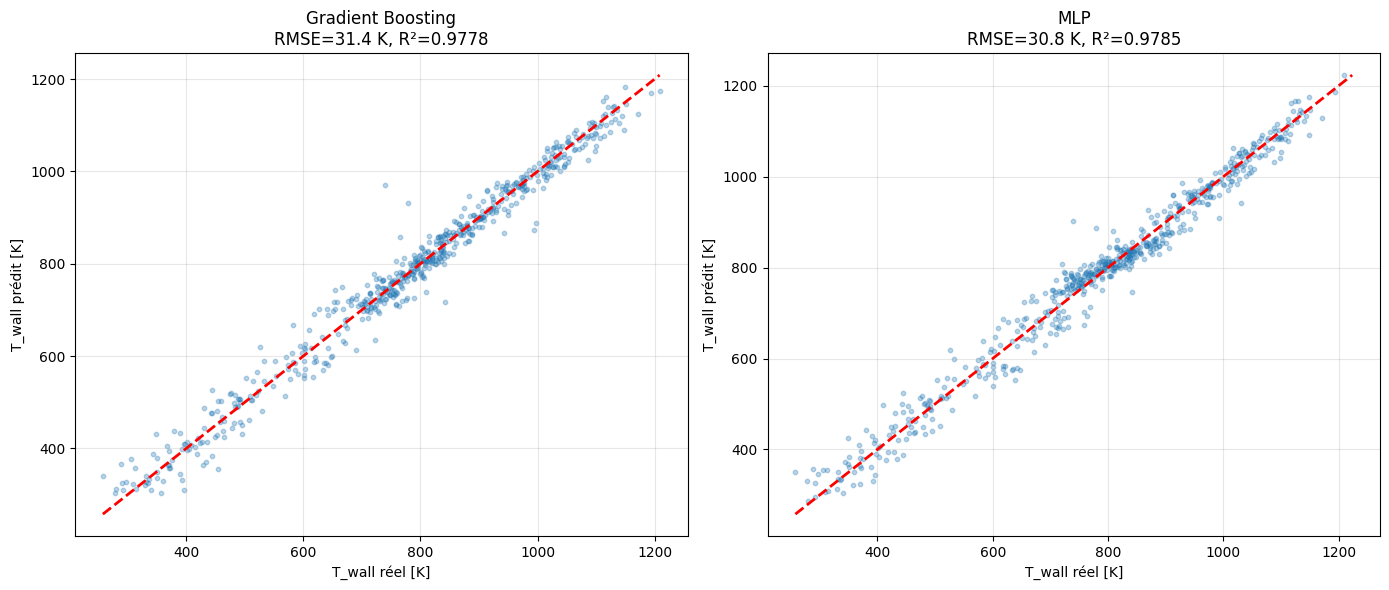

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, name in [(ax1, y_pred_gb, "Gradient Boosting"), (ax2, y_pred_mlp, "MLP")]:
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=2)
    ax.set_xlabel("T_wall réel [K]")
    ax.set_ylabel("T_wall prédit [K]")
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f"{name}\nRMSE={rmse:.1f} K, R²={r2:.4f}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regression_results.png", dpi=150, bbox_inches="tight")
plt.show()


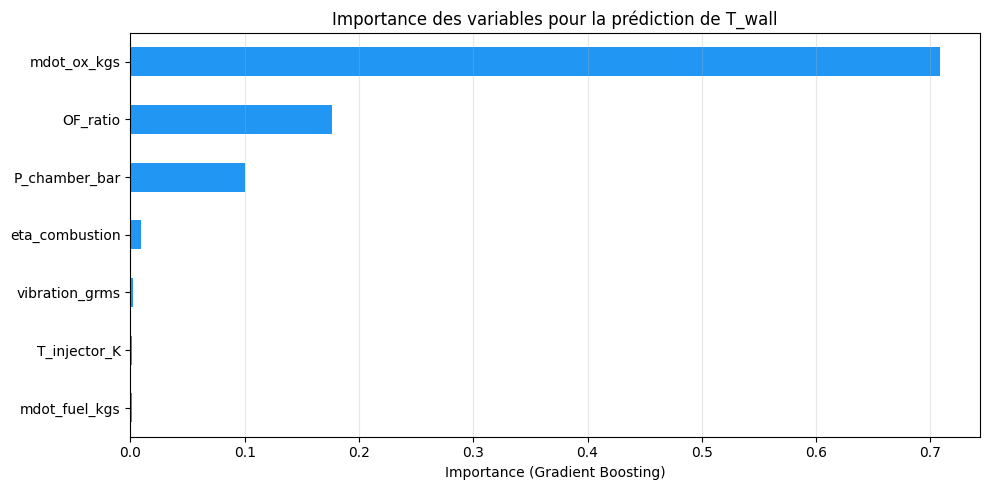

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
importances = pd.Series(gb.feature_importances_, index=predictors).sort_values(ascending=True)
importances.plot(kind="barh", ax=ax, color="#2196F3")
ax.set_xlabel("Importance (Gradient Boosting)")
ax.set_title("Importance des variables pour la prédiction de T_wall")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## Conclusions

### Clustering
- **K-Means (K=3)** retrouve correctement les 3 régimes de fonctionnement du moteur
- **DBSCAN** identifie des structures de densité variable et détecte les points hors régime

### Réduction de dimensions
- **PCA** : les 2 premières composantes capturent la majorité de la variance, dominées par la pression chambre et le ratio O/F
- **t-SNE** : séparation nette des 3 régimes, confirmant leur distinctivité dans l'espace des features

### Régression
- Le **Gradient Boosting** prédit efficacement T_wall avec un R² élevé
- Les variables les plus influentes sont le ratio O/F et la pression chambre, cohérent avec la physique de la combustion

### Applications industrielles
Ces techniques permettent en contexte réel de :
- Classifier automatiquement les phases de fonctionnement d'un moteur
- Détecter des anomalies (points de bruit DBSCAN)
- Construire des modèles réduits pour le monitoring temps réel
